#  Naive Bayes Classifier - Beginner-Friendly Example
```
  Dataset: Student Pass/Fail Prediction

SCENARIO:
We want to predict whether a student will PASS or FAIL
based on three features:
  - Hours studied per day
  - Attendance percentage
  - Previous exam score (out of 100)

We'll use Gaussian Naive Bayes since our features are
continuous numerical values.


# 1. IMPORTS 

In [1]:

import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# 2. GENERATE DATASET 

In [2]:
np.random.seed(42)  # for reproducibility

n_samples = 200

# PASSING students (label = 1)
# Tend to study more, attend more, scored higher before
pass_hours      = np.random.normal(loc=5.0, scale=1.2, size=n_samples // 2)
pass_attendance = np.random.normal(loc=80,  scale=8.0, size=n_samples // 2)
pass_prev_score = np.random.normal(loc=72,  scale=10,  size=n_samples // 2)

# FAILING students (label = 0)
# Tend to study less, attend less, scored lower before
fail_hours      = np.random.normal(loc=2.0, scale=1.0, size=n_samples // 2)
fail_attendance = np.random.normal(loc=55,  scale=10,  size=n_samples // 2)
fail_prev_score = np.random.normal(loc=45,  scale=12,  size=n_samples // 2)

# Clip values to realistic ranges
pass_hours      = np.clip(pass_hours,      0, 12)
pass_attendance = np.clip(pass_attendance, 0, 100)
pass_prev_score = np.clip(pass_prev_score, 0, 100)
fail_hours      = np.clip(fail_hours,      0, 12)
fail_attendance = np.clip(fail_attendance, 0, 100)
fail_prev_score = np.clip(fail_prev_score, 0, 100)

# Combine into a single DataFrame
df = pd.DataFrame({
    "hours_studied":   np.concatenate([pass_hours, fail_hours]),
    "attendance_pct":  np.concatenate([pass_attendance, fail_attendance]),
    "prev_exam_score": np.concatenate([pass_prev_score, fail_prev_score]),
    "result":          [1] * (n_samples // 2) + [0] * (n_samples // 2),
})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 55)
print("  DATASET PREVIEW")
print("=" * 55)
print(df.head(10).to_string(index=False))
print(f"\nTotal samples : {len(df)}")
print(f"Passing (1)   : {df['result'].sum()}")
print(f"Failing (0)   : {(df['result'] == 0).sum()}")


  DATASET PREVIEW
 hours_studied  attendance_pct  prev_exam_score  result
      3.243782       83.082539        65.070904       1
      4.325255       82.412379        79.589692       1
      4.277952       67.594693        64.696334       1
      2.322719       49.463507        49.733426       0
      2.624120       65.584245        48.116670       0
      2.021004       47.515135        54.064695       0
      4.225856       73.970111        73.307406       1
      2.024510       52.249483        45.221021       0
      4.153182       71.449677        54.952867       0
      4.136187       86.254583        68.654988       1

Total samples : 200
Passing (1)   : 100
Failing (0)   : 100


# 3. SPLIT FEATURES AND LABEL 

In [9]:
X = df[["hours_studied", "attendance_pct", "prev_exam_score"]]
y = df["result"]

In [14]:
print(X.loc[0])
print("\nlabel:", y[0])

hours_studied       3.243782
attendance_pct     83.082539
prev_exam_score    65.070904
Name: 0, dtype: float64

label: 1


In [15]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 160
Testing  samples : 40


# 4. TRAIN THE MODEL

In [4]:
model = GaussianNB()
model.fit(X_train, y_train)
print("\n✅ Model trained successfully!")


✅ Model trained successfully!


# 5. MAKE PREDICTIONS

In [16]:
y_pred = model.predict(X_test)

In [20]:
# compare actual vs predict
print("actual :", list(y_test)[:10])
print("predict:", list(y_pred)[:10])

actual : [0, 0, 1, 1, 1, 0, 0, 1, 0, 0]
predict: [0, 0, 1, 1, 1, 0, 0, 1, 0, 0]


# 6. EVALUATE THE MODEL

In [6]:

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 55)
print("  MODEL EVALUATION")
print("=" * 55)
print(f"Accuracy : {accuracy * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))



  MODEL EVALUATION
Accuracy : 97.5%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.95      1.00      0.97        18
        Pass       1.00      0.95      0.98        22

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



# 7. CONFUSION MATRIX

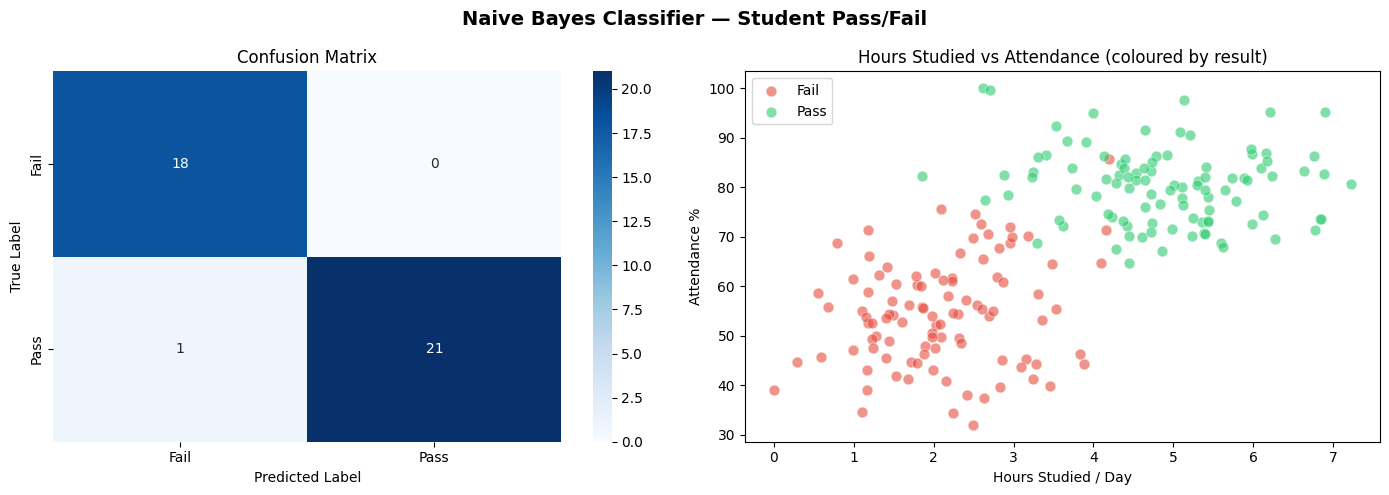


📊 Chart saved as naive_bayes_results.png


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Naive Bayes Classifier — Student Pass/Fail", fontsize=14, fontweight="bold")

# Plot 1: Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"],
    ax=axes[0],
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title("Confusion Matrix")

# Plot 2: Feature distributions by outcome
colors = {0: "#e74c3c", 1: "#2ecc71"}
labels = {0: "Fail", 1: "Pass"}
for label, color in colors.items():
    subset = df[df["result"] == label]
    axes[1].scatter(
        subset["hours_studied"],
        subset["attendance_pct"],
        c=color,
        label=labels[label],
        alpha=0.6,
        edgecolors="white",
        linewidths=0.5,
        s=60,
    )
axes[1].set_xlabel("Hours Studied / Day")
axes[1].set_ylabel("Attendance %")
axes[1].set_title("Hours Studied vs Attendance (coloured by result)")
axes[1].legend()

plt.tight_layout()
plt.savefig("naive_bayes_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Chart saved as naive_bayes_results.png")


# 8. PREDICT FOR NEW STUDENTS 


In [21]:

print("\n" + "=" * 55)
print("  PREDICTING FOR NEW STUDENTS")
print("=" * 55)

new_students = pd.DataFrame({
    "hours_studied":   [6.5, 1.5, 4.0],
    "attendance_pct":  [88,  42,  65],
    "prev_exam_score": [78,  35,  58],
})

predictions  = model.predict(new_students)
probabilities = model.predict_proba(new_students)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    outcome = "PASS" if pred == 1 else "FAIL"
    print(
        f"Student {i+1}: hours={new_students.iloc[i,0]}, "
        f"attendance={new_students.iloc[i,1]}%, "
        f"prev_score={new_students.iloc[i,2]}"
    )
    print(f"  → Prediction : {outcome}")
    print(f"  → Confidence : Fail={prob[0]*100:.1f}%  Pass={prob[1]*100:.1f}%\n")



  PREDICTING FOR NEW STUDENTS
Student 1: hours=6.5, attendance=88%, prev_score=78
  → Prediction : PASS
  → Confidence : Fail=0.0%  Pass=100.0%

Student 2: hours=1.5, attendance=42%, prev_score=35
  → Prediction : FAIL
  → Confidence : Fail=100.0%  Pass=0.0%

Student 3: hours=4.0, attendance=65%, prev_score=58
  → Prediction : PASS
  → Confidence : Fail=43.5%  Pass=56.5%

